# 09 Conditional Predictions: 

**Question:** how does the models prediction improve if I already know the outcomes of earlier rounds?

Instead of predicting only from the pre playoff view (16 teams), I also simulate from these viewpoints:
- **Round 2 (8 teams):** R1 winners known - who takes the title?
- **Conference Finals (4 teams):** R1+R2 winners known - final four.
- **Finals (2 teams):** everything known except the finals itself.

The hit rate should rise with each step. The shape of the rise tells me where the uncertainty actually sits

## 1. Setup (same engine as NB_08)

In [1]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   # only used for the heatmap

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

DATA = Path("..") / "data" / "processed"
df = pd.read_parquet(DATA / "games_with_advanced_features.parquet")
playoffs = df[df.gameType == "Playoffs"].copy()
playoffs["team_pair"] = playoffs.apply(lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1)

team_names = pd.concat([
    df[["hometeamId", "hometeamName"]].rename(columns={"hometeamId": "teamId", "hometeamName": "teamName"}),
    df[["awayteamId", "awayteamName"]].rename(columns={"awayteamId": "teamId", "awayteamName": "teamName"}),
]).drop_duplicates("teamId").set_index("teamId")["teamName"]

# pre-playoff ELO
home_view = playoffs[["season", "gameDate", "hometeamId", "home_elo_pre"]].rename(
    columns={"hometeamId": "teamId", "home_elo_pre": "elo"})
away_view = playoffs[["season", "gameDate", "awayteamId", "away_elo_pre"]].rename(
    columns={"awayteamId": "teamId", "away_elo_pre": "elo"})
team_view = pd.concat([home_view, away_view], ignore_index=True).sort_values(["season", "teamId", "gameDate"])
preplayoff_elo = team_view.groupby(["season", "teamId"], as_index=False).first()
print("Data loaded.")

Data loaded.


In [2]:
HOME_ADV = 100

def elo_p(t_elo, o_elo, is_home):
    delta = o_elo - t_elo - (HOME_ADV if is_home else -HOME_ADV)
    return 1.0 / (1.0 + 10 ** (delta / 400))

def simulate_b07(higher_elo, lower_elo, rng):
    home_pattern = [True, True, False, False, True, False, True]
    wh = wl = 0
    for is_h_home in home_pattern:
        if rng.random() < elo_p(higher_elo, lower_elo, is_h_home): wh += 1
        else: wl += 1
        if wh == 4: return True
        if wl == 4: return False
    return wh > wl

def build_bracket_for_season(season):
    s_games = playoffs[playoffs.season == season]
    series_list = []
    
    for pair, grp in s_games.groupby("team_pair"):
        
        if len(grp) < 3: return None
        
        higher = grp.hometeamId.value_counts().idxmax()
        lower = [t for t in pair if t != higher][0]
        wins_h = ((grp.hometeamId == higher) & (grp.home_win == 1)).sum() + \
                 ((grp.awayteamId == higher) & (grp.home_win == 0)).sum()
        
        higher_won = wins_h > (len(grp) - wins_h)
        winner = higher if higher_won else lower
        
        series_list.append({"higher": higher, "lower": lower, "winner": winner,
                            "first_date": grp.gameDate.min()})
    
    
    s = pd.DataFrame(series_list).sort_values("first_date").reset_index(drop=True)
    
    if len(s) != 15: return None
    
    s["round"] = [1]*8 + [2]*4 + [3]*2 + [4]
    s["uid"] = range(len(s))
    s["parents"] = [[] for _ in range(len(s))]
    
    for r in [2, 3, 4]:
        higher_round = s[s["round"] == r]
        lower_round = s[s["round"] == r - 1]
        
        for idx, row in higher_round.iterrows():
            here = {row.higher, row.lower}
            parents = [low.uid for _, low in lower_round.iterrows() if low.winner in here]
            
            if len(parents) != 2: return None
            s.at[idx, "parents"] = parents
    
    return s

valid_seasons = [s for s in sorted(playoffs.season.unique()) if build_bracket_for_season(s) is not None]
print(f"Valid seasons: {len(valid_seasons)}")

Valid seasons: 40


## 2. Conditional simulation

Simulate all series from `start_round` onwards, fix all earlier series to their actual winners

In [3]:
# cache brackets + ELOs 
print("Building all brackets")
bracket_cache = {s: build_bracket_for_season(s) for s in valid_seasons}
elo_cache = {}

for s in valid_seasons:
    teams = sorted(set(bracket_cache[s].higher) | set(bracket_cache[s].lower))
    elo_cache[s] = {t: float(preplayoff_elo[(preplayoff_elo.season == s) & (preplayoff_elo.teamId == t)].iloc[0].elo)
                    for t in teams}

# convert bracket rows to plain dict lists

bracket_rows = {s: bracket_cache[s][["uid", "round", "higher", "lower", "winner", "parents"]].to_dict("records")
                for s in valid_seasons}

print(f"Cache built for {len(bracket_cache)} seasons.")


def champ_probs_from(season, start_round, n_sim=2000):
    rows = bracket_rows[season]
    elos = elo_cache[season]
    teams = list(elos.keys())
    rng = np.random.default_rng(season * 10 + start_round)
    pre_winners = {r["uid"]: r["winner"] for r in rows if r["round"] < start_round}

    counts = {t: 0 for t in teams}
    
    for _ in range(n_sim):
        winners = dict(pre_winners)
        
        for r in rows:
            
            if r["uid"] in winners: continue
            
            if r["round"] == 1:
                a, b = r["higher"], r["lower"]
            
            else:
                a = winners[r["parents"][0]]
                b = winners[r["parents"][1]]
            
            
            elo_a, elo_b = elos[a], elos[b]
            higher, lower = (a, b) if elo_a >= elo_b else (b, a)
            winners[r["uid"]] = higher if simulate_b07(elos[higher], elos[lower], rng) else lower
        
        
        finals_uid = next(r["uid"] for r in rows if r["round"] == 4)
        counts[winners[finals_uid]] += 1
    
    return {t: c / n_sim for t, c in counts.items()}, bracket_cache[season]

Building all brackets


Cache built for 40 seasons.


In [4]:
round_names = {1: "Pre-Playoffs (16)", 2: "Round 2 (8)", 3: "Conference Finals (4)", 4: "Finals (2)"}

results = []

for season in valid_seasons:
    
    for start_round in [1, 2, 3, 4]:
        out = champ_probs_from(season, start_round, n_sim=3000)
        
        if out is None: continue
        probs, bracket = out
        actual = bracket[bracket["round"] == 4].iloc[0].winner
        ranked = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
        rank = next(i for i, (t, _) in enumerate(ranked) if t == actual) + 1
        
        results.append({
            "season": season, "start_round": start_round,
            "actual": team_names.get(actual, str(actual)),
            "top_pick": team_names.get(ranked[0][0], str(ranked[0][0])),
            "p_actual": probs[actual], "rank_actual": rank,
            "p_top": ranked[0][1], "is_top1": rank == 1,})

        
results = pd.DataFrame(results)

print(f"{len(results)} data points computed.")

160 data points computed.


## 4. Hit rate as a function of starting point

In [5]:
summary = results.groupby('start_round').agg(
    n_seasons=('season', 'count'),
    top1_hit_rate=('rank_actual', lambda r: (r == 1).mean()),
    top3_hit_rate=('rank_actual', lambda r: (r <= 3).mean()),
    avg_p_actual=('p_actual', 'mean'),
).round(3)
summary.index = summary.index.map(round_names)
summary

,n_seasons,top1_hit_rate,top3_hit_rate,avg_p_actual
start_round,,,,
Pre-Playoffs (16),40,0.525,0.750,0.339
Round 2 (8),40,0.525,0.825,0.367
Conference Finals (4),40,0.575,0.875,0.451
Finals (2),40,0.775,1.000,0.663


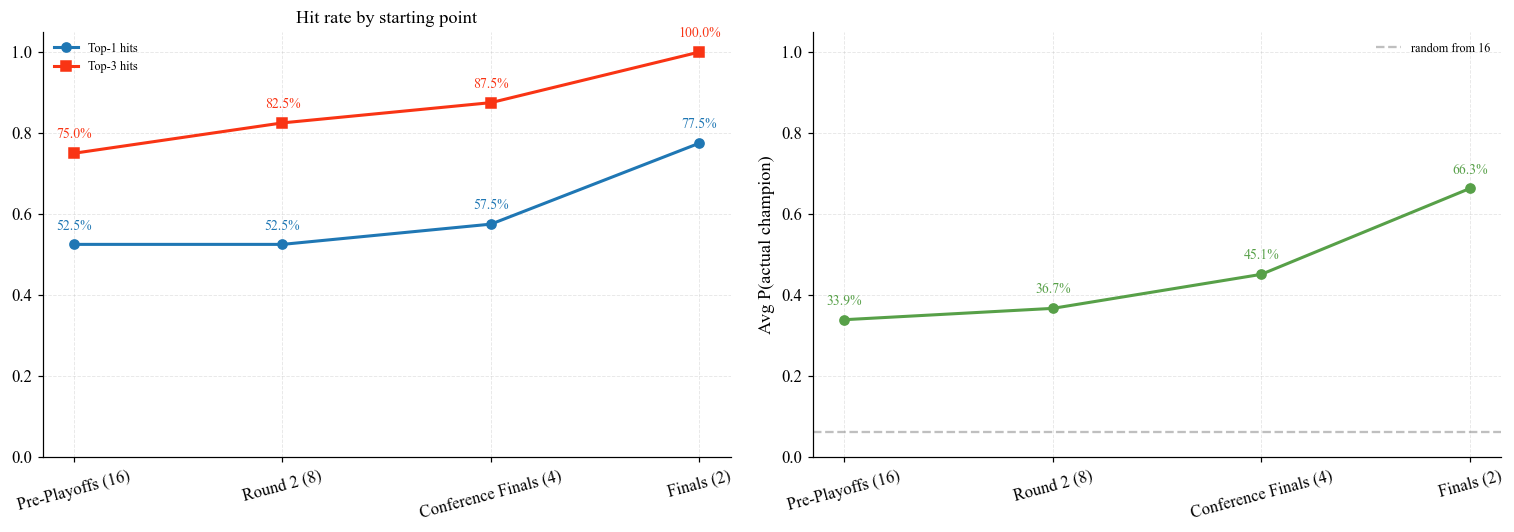


Values:
                       top1_pp  top3_pp  avg_p_pp
start_round                                      
Pre-Playoffs (16)         52.5     75.0      33.9
Round 2 (8)               52.5     82.5      36.7
Conference Finals (4)     57.5     87.5      45.1
Finals (2)                77.5    100.0      66.3


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = list(round_names.values())


axes[0].plot(x, summary.top1_hit_rate, marker="o", linewidth=2, color="#1f77b4", label="Top-1 hits")
axes[0].plot(x, summary.top3_hit_rate, marker="s", linewidth=2, color="#f93414", label="Top-3 hits")
axes[0].set_title("Hit rate by starting point")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].tick_params(axis="x", rotation=15)


for i, (v1, v3) in enumerate(zip(summary.top1_hit_rate, summary.top3_hit_rate)):
    axes[0].annotate(f"{v1:.1%}", (i, v1), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="#1f77b4")
    axes[0].annotate(f"{v3:.1%}", (i, v3), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="#f93414")


axes[1].plot(x, summary.avg_p_actual, marker="o", linewidth=2, color="#57A048")
axes[1].axhline(1/16, color="gray", linestyle="--", alpha=0.5, label="random from 16")
axes[1].set_ylabel("Avg P(actual champion)")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].tick_params(axis="x", rotation=15)


for i, v in enumerate(summary.avg_p_actual):
    axes[1].annotate(f"{v:.1%}", (i, v), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="#57A048")

plt.tight_layout()
plt.show()

# print the underlying numbers as %

print("\nValues:")
print(summary.assign(
    top1_pp=lambda d: (d.top1_hit_rate * 100).round(1),
    top3_pp=lambda d: (d.top3_hit_rate * 100).round(1),
    avg_p_pp=lambda d: (d.avg_p_actual * 100).round(1),
)[["top1_pp", "top3_pp", "avg_p_pp"]].to_string())




## 5. Heatmap for season confidence for the actual champion


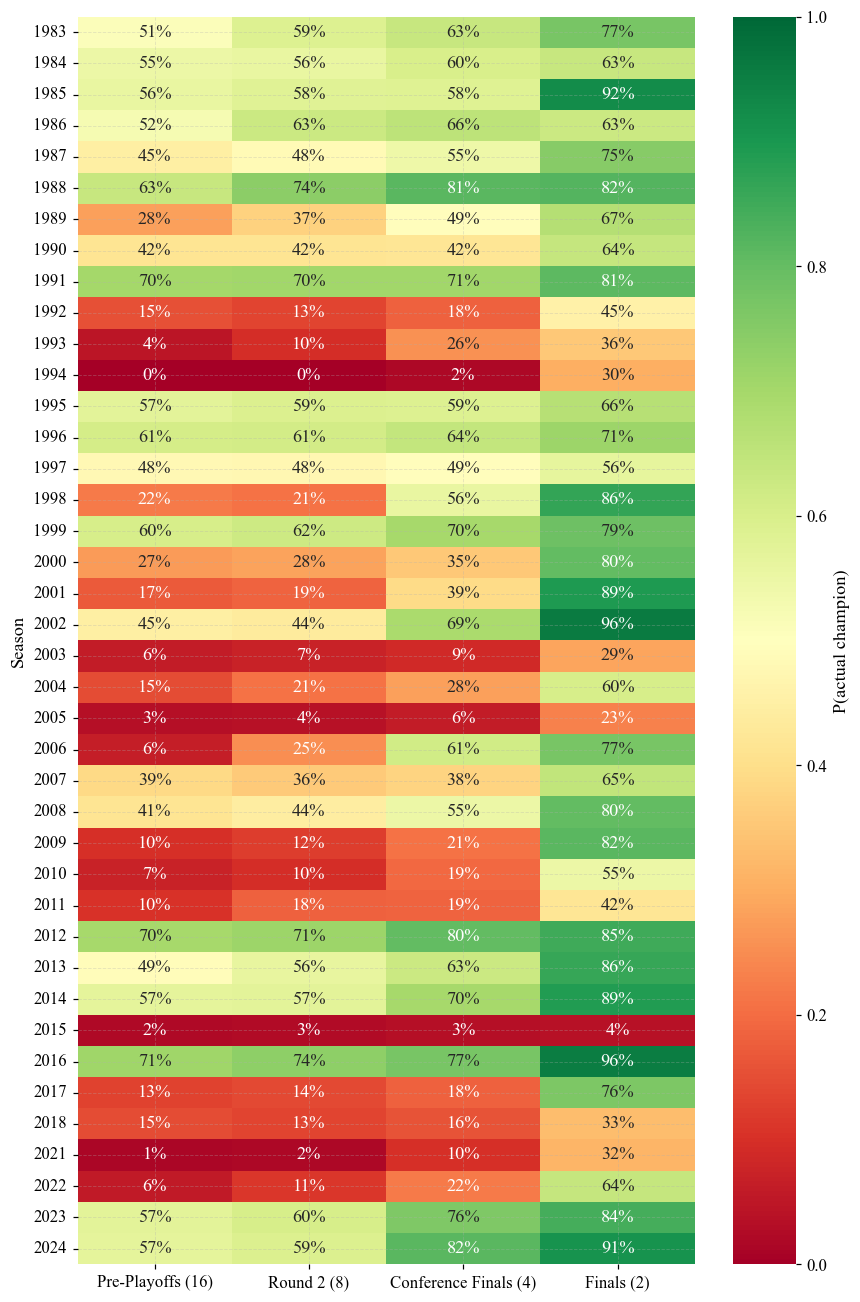

In [7]:
pivot = results.pivot(index="season", columns="start_round", values="p_actual")
pivot.columns = [round_names[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(pivot, cmap="RdYlGn", vmin=0, vmax=1, annot=True, fmt=".0%",
            cbar_kws={"label": "P(actual champion)"}, ax=ax)

ax.set_ylabel("Season")
plt.tight_layout()
plt.show()

## 6. Checking the suprise outcomes:

In [8]:
wide = results.pivot(index='season', columns='start_round', values='p_actual')

wide['delta_to_finals'] = wide[4] - wide[1]

surprises = wide.sort_values('delta_to_finals', ascending=False).head(8)

champs = results[results.start_round == 1].set_index('season').actual

surprises['actual_champion'] = surprises.index.map(champs)
surprises[[1, 2, 3, 4, 'actual_champion']].rename(columns={1:'Pre-PO', 2:'R2', 3:'CF', 4:'Finals'}).round(3)

start_round,Pre-PO,R2,CF,Finals,actual_champion
season,,,,,
2001,0.168,0.185,0.392,0.894,Lakers
2009,0.099,0.122,0.209,0.816,Lakers
2006,0.065,0.253,0.614,0.770,Spurs
1998,0.222,0.208,0.558,0.864,Spurs
2017,0.129,0.143,0.183,0.764,Warriors
2022,0.058,0.110,0.221,0.637,Nuggets
2000,0.272,0.282,0.354,0.804,Lakers
2002,0.446,0.437,0.688,0.959,Spurs


## 7. Save

In [9]:
results.to_csv(DATA / "conditional_predictions.csv", index=False)
print("Saved.")

Saved.
